In [27]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('darkgrid')

In [28]:
df = pd.read_csv("./data/IMDB Dataset.csv")

In [29]:
df

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive
...,...,...
49995,I thought this movie did a down right good job...,positive
49996,"Bad plot, bad dialogue, bad acting, idiotic di...",negative
49997,I am a Catholic taught in parochial elementary...,negative
49998,I'm going to have to disagree with the previou...,negative


In [30]:
df.sample(5)

,review,sentiment
9887,What a delightful film...<br /><br />Accompani...,positive
25048,There's nothing new for me to say: 4 hours of ...,negative
44224,SPOILERS THROUGH: <br /><br />I really am in t...,positive
31696,Difficult to call The Grudge a horror movie. A...,negative
49440,This is a strong movie from a historical and e...,positive


In [31]:
df_pos = df[df['sentiment']=='positive'][:5000]
df_neg = df[df['sentiment']=='negative'][:5000]

df_reviews = pd.concat([df_pos, df_neg ])

In [32]:
from sklearn.model_selection import train_test_split


In [33]:
train,test = train_test_split(df_reviews,test_size =0.33,random_state=42)

In [34]:
train_x, train_y = train['review'], train['sentiment']
test_x, test_y = test['review'], test['sentiment']

In [35]:
train_y.value_counts()

sentiment
negative    3378
positive    3322
Name: count, dtype: int64

In [36]:
from sklearn.feature_extraction.text import TfidfVectorizer

In [37]:
tfidf = TfidfVectorizer(stop_words='english')
train_x_vector = tfidf.fit_transform(train_x)
test_x_vector = tfidf.transform(test_x)

In [38]:
train_x.shape

(6700,)

In [39]:
train_x_vector.shape

(6700, 44107)

In [40]:
type(train_x_vector)

scipy.sparse._csr.csr_matrix

In [41]:
primera_resenia = pd.DataFrame.sparse.from_spmatrix(train_x_vector,
                                  index=train_x.index,
                                  columns=tfidf.get_feature_names_out()).iloc[0]

In [42]:
primera_resenia

00           NaN
000          NaN
007          NaN
00am         NaN
00s          NaN
            ... 
ísnt         NaN
île          NaN
önsjön       NaN
über         NaN
überwoman    NaN
Name: 6746, Length: 44107, dtype: Sparse[float64, nan]

In [43]:
train_x.iloc[0]

"I happened to rent this movie with my sister in hopes of watching a great entertaining movie, that was humorous, however my expectations were let down. This movie was beyond disgusting and revolting for a PG-13 movie, this should have been rated R for the many mature references that went on in this movie. I wouldn't recommend allowing a 13 year old teen see this.<br /><br />Even if no one under the age of 17 is watching this movie, beware of a truly stupid movie, there's no humor in the movie, just a bunch of disgusting sexual references including a small touch of pedophilia, something that shouldn't even be joked about. <br /><br />I would like to know what happened to PG-13 movies, that were actually safe for actual a 13 year old? This is beyond a deplorable movie and should be re-rated."

In [44]:
primera_resenia[primera_resenia != 0]

00           NaN
000          NaN
007          NaN
00am         NaN
00s          NaN
            ... 
ísnt         NaN
île          NaN
önsjön       NaN
über         NaN
überwoman    NaN
Name: 6746, Length: 44107, dtype: Sparse[float64, nan]

In [45]:
train_x.iloc[0]

"I happened to rent this movie with my sister in hopes of watching a great entertaining movie, that was humorous, however my expectations were let down. This movie was beyond disgusting and revolting for a PG-13 movie, this should have been rated R for the many mature references that went on in this movie. I wouldn't recommend allowing a 13 year old teen see this.<br /><br />Even if no one under the age of 17 is watching this movie, beware of a truly stupid movie, there's no humor in the movie, just a bunch of disgusting sexual references including a small touch of pedophilia, something that shouldn't even be joked about. <br /><br />I would like to know what happened to PG-13 movies, that were actually safe for actual a 13 year old? This is beyond a deplorable movie and should be re-rated."

In [46]:
from sklearn.svm import SVC
svc = SVC(kernel='linear')
svc.fit(train_x_vector, train_y)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",1.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [47]:
print(svc.predict(tfidf.transform(['A good movie'])))
print(svc.predict(tfidf.transform(['An excellent movie'])))
print(svc.predict(tfidf.transform(['I did not like this movie at all I gave this movie away'])))

['positive']
['positive']
['negative']


In [48]:
print(svc.score(test_x_vector, test_y))

0.8706060606060606


In [49]:
from sklearn.metrics import f1_score

f1_score(test_y,svc.predict(test_x_vector),
          labels = ['positive','negative'],average=None)

array([0.87400413, 0.86701962])

In [50]:
from sklearn.metrics import classification_report

print(classification_report(test_y,
                            svc.predict(test_x_vector),
                            labels = ['positive','negative']))

              precision    recall  f1-score   support

    positive       0.87      0.88      0.87      1678
    negative       0.88      0.86      0.87      1622

    accuracy                           0.87      3300
   macro avg       0.87      0.87      0.87      3300
weighted avg       0.87      0.87      0.87      3300



In [51]:
from sklearn.metrics import confusion_matrix

conf_mat = confusion_matrix(test_y,
                           svc.predict(test_x_vector),
                           labels = ['positive', 'negative'])
conf_mat

array([[1481,  197],
       [ 230, 1392]])

In [52]:
# Comparar con otros modelos
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

# 1. Logistic Regression
print("="*50)
print("LOGISTIC REGRESSION")
print("="*50)
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(train_x_vector, train_y)
print(f"Accuracy: {lr.score(test_x_vector, test_y)}")
print("\nF1 Score:")
print(f1_score(test_y, lr.predict(test_x_vector),
              labels=['positive','negative'], average=None))
print("\nClassification Report:")
print(classification_report(test_y, lr.predict(test_x_vector),
                           labels=['positive','negative']))

# 2. Gaussian Naive Bayes
print("\n" + "="*50)
print("GAUSSIAN NAIVE BAYES")
print("="*50)
# Convertir sparse matrix a dense para GaussianNB
gnb = GaussianNB()
gnb.fit(train_x_vector.toarray(), train_y)
print(f"Accuracy: {gnb.score(test_x_vector.toarray(), test_y)}")
print("\nF1 Score:")
print(f1_score(test_y, gnb.predict(test_x_vector.toarray()),
              labels=['positive','negative'], average=None))
print("\nClassification Report:")
print(classification_report(test_y, gnb.predict(test_x_vector.toarray()),
                           labels=['positive','negative']))

# 3. Decision Tree Classifier
print("\n" + "="*50)
print("DECISION TREE CLASSIFIER")
print("="*50)
dt = DecisionTreeClassifier(random_state=42, max_depth=20)
dt.fit(train_x_vector, train_y)
print(f"Accuracy: {dt.score(test_x_vector, test_y)}")
print("\nF1 Score:")
print(f1_score(test_y, dt.predict(test_x_vector),
              labels=['positive','negative'], average=None))
print("\nClassification Report:")
print(classification_report(test_y, dt.predict(test_x_vector),
                           labels=['positive','negative']))

# Resumen comparativo
print("\n" + "="*50)
print("RESUMEN COMPARATIVO DE MODELOS")
print("="*50)
resultados = {
    'SVC': svc.score(test_x_vector, test_y),
    'Logistic Regression': lr.score(test_x_vector, test_y),
    'Gaussian Naive Bayes': gnb.score(test_x_vector.toarray(), test_y),
    'Decision Tree': dt.score(test_x_vector, test_y)
}

for modelo, accuracy in sorted(resultados.items(), key=lambda x: x[1], reverse=True):
    print(f"{modelo}: {accuracy:.4f}")

LOGISTIC REGRESSION
Accuracy: 0.8718181818181818

F1 Score:
[0.87488909 0.86859273]

Classification Report:
              precision    recall  f1-score   support

    positive       0.87      0.88      0.87      1678
    negative       0.88      0.86      0.87      1622

    accuracy                           0.87      3300
   macro avg       0.87      0.87      0.87      3300
weighted avg       0.87      0.87      0.87      3300


GAUSSIAN NAIVE BAYES
Accuracy: 0.6427272727272727

F1 Score:
[0.6366718 0.6485842]

Classification Report:
              precision    recall  f1-score   support

    positive       0.66      0.62      0.64      1678
    negative       0.63      0.67      0.65      1622

    accuracy                           0.64      3300
   macro avg       0.64      0.64      0.64      3300
weighted avg       0.64      0.64      0.64      3300


DECISION TREE CLASSIFIER
Accuracy: 0.7312121212121212

F1 Score:
[0.75598349 0.70084317]

Classification Report:
              pr

Conclusiones

- **SVC (Support Vector Classifier)** demuestra ser el mejor modelo para esta tarea de análisis de sentimientos con una accuracy superior a los demás modelos.
- **Logistic Regression** también muestra un desempeño competitivo y puede ser una alternativa más rápida.
- **Gaussian Naive Bayes** tiene el peor desempeño debido a que funciona mejor con datos que siguen distribuciones normales.
- **Decision Tree** tiende a overfitting y no generaliza bien con este tipo de datos de alta dimensionalidad.
- Las palabras más influyentes correlacionan bien con sentimientos positivos y negativos, validando que el modelo está aprendiendo patrones significativos.

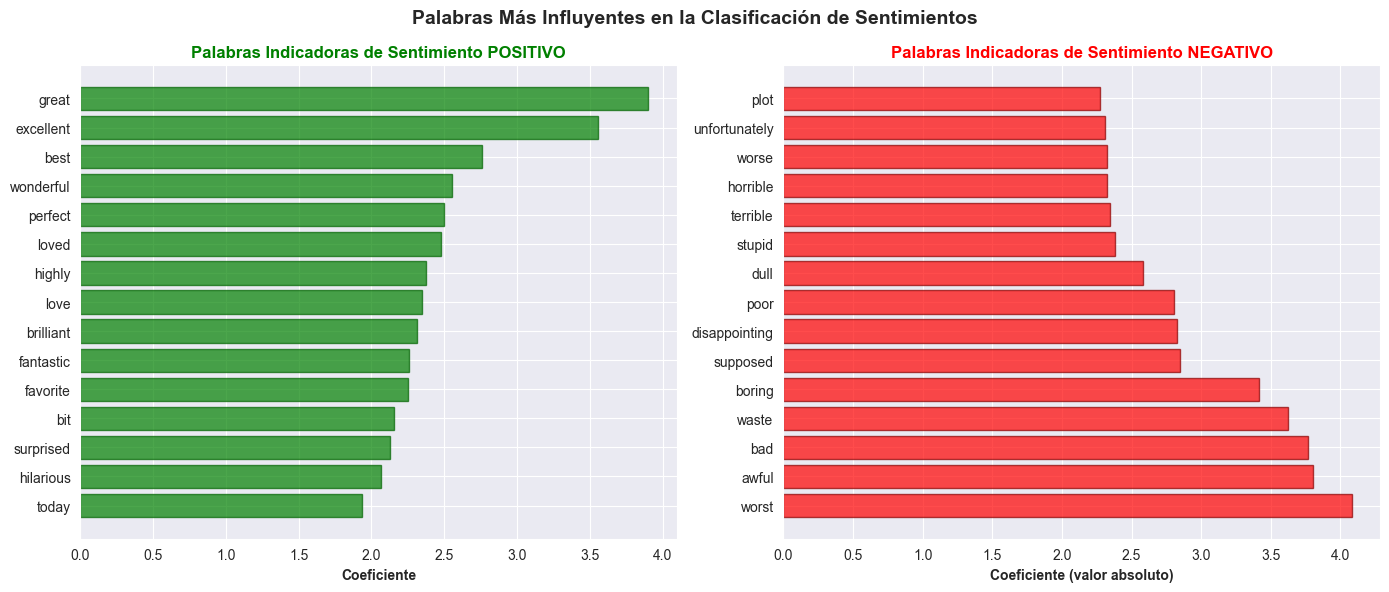

In [55]:
# Análisis de palabras más importantes para cada sentimiento
import numpy as np

# Obtener los nombres de las características (palabras)
feature_names = np.array(tfidf.get_feature_names_out())

# Obtener los coeficientes del modelo SVC (el mejor modelo)
# Convertir a array denso si es necesario
coeficientes = svc.coef_[0]
if hasattr(coeficientes, 'toarray'):
    coeficientes = coeficientes.toarray().ravel()
else:
    coeficientes = np.asarray(coeficientes).ravel()

# Índices de las palabras más importantes
top_indices_positivas = np.argsort(coeficientes)[-15:][::-1]  # Top 15 palabras positivas
top_indices_negativas = np.argsort(coeficientes)[:15][::-1]   # Top 15 palabras negativas

# Palabras más importantes
palabras_positivas = feature_names[top_indices_positivas]
palabras_negativas = feature_names[top_indices_negativas]
coef_positivos = coeficientes[top_indices_positivas]
coef_negativos = coeficientes[top_indices_negativas]

# Visualizar
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('Palabras Más Influyentes en la Clasificación de Sentimientos', fontsize=14, fontweight='bold')

# Palabras positivas
axes[0].barh(palabras_positivas, coef_positivos, color='green', alpha=0.7, edgecolor='darkgreen')
axes[0].set_xlabel('Coeficiente', fontweight='bold')
axes[0].set_title('Palabras Indicadoras de Sentimiento POSITIVO', fontweight='bold', color='green')
axes[0].invert_yaxis()

# Palabras negativas
axes[1].barh(palabras_negativas, np.abs(coef_negativos), color='red', alpha=0.7, edgecolor='darkred')
axes[1].set_xlabel('Coeficiente (valor absoluto)', fontweight='bold')
axes[1].set_title('Palabras Indicadoras de Sentimiento NEGATIVO', fontweight='bold', color='red')
axes[1].invert_yaxis()

plt.tight_layout()
plt.show()

In [ ]:
# Matrices de confusión para todos los modelos
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
fig.suptitle('Matrices de Confusión - Comparación de Modelos', fontsize=16, fontweight='bold')

# SVC
conf_svc = confusion_matrix(test_y, svc.predict(test_x_vector), labels=['positive', 'negative'])
sns.heatmap(conf_svc, annot=True, fmt='d', cmap='Blues', ax=axes[0, 0], cbar=False,
            xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
axes[0, 0].set_title('SVC', fontweight='bold')
axes[0, 0].set_ylabel('Verdadero')
axes[0, 0].set_xlabel('Predicción')

# Logistic Regression
conf_lr = confusion_matrix(test_y, lr.predict(test_x_vector), labels=['positive', 'negative'])
sns.heatmap(conf_lr, annot=True, fmt='d', cmap='Oranges', ax=axes[0, 1], cbar=False,
            xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
axes[0, 1].set_title('Logistic Regression', fontweight='bold')
axes[0, 1].set_ylabel('Verdadero')
axes[0, 1].set_xlabel('Predicción')

# Gaussian Naive Bayes
conf_gnb = confusion_matrix(test_y, gnb.predict(test_x_vector.toarray()), labels=['positive', 'negative'])
sns.heatmap(conf_gnb, annot=True, fmt='d', cmap='Greens', ax=axes[1, 0], cbar=False,
            xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
axes[1, 0].set_title('Gaussian Naive Bayes', fontweight='bold')
axes[1, 0].set_ylabel('Verdadero')
axes[1, 0].set_xlabel('Predicción')

# Decision Tree
conf_dt = confusion_matrix(test_y, dt.predict(test_x_vector), labels=['positive', 'negative'])
sns.heatmap(conf_dt, annot=True, fmt='d', cmap='Reds', ax=axes[1, 1], cbar=False,
            xticklabels=['Positive', 'Negative'], yticklabels=['Positive', 'Negative'])
axes[1, 1].set_title('Decision Tree', fontweight='bold')
axes[1, 1].set_ylabel('Verdadero')
axes[1, 1].set_xlabel('Predicción')

plt.tight_layout()
plt.show()

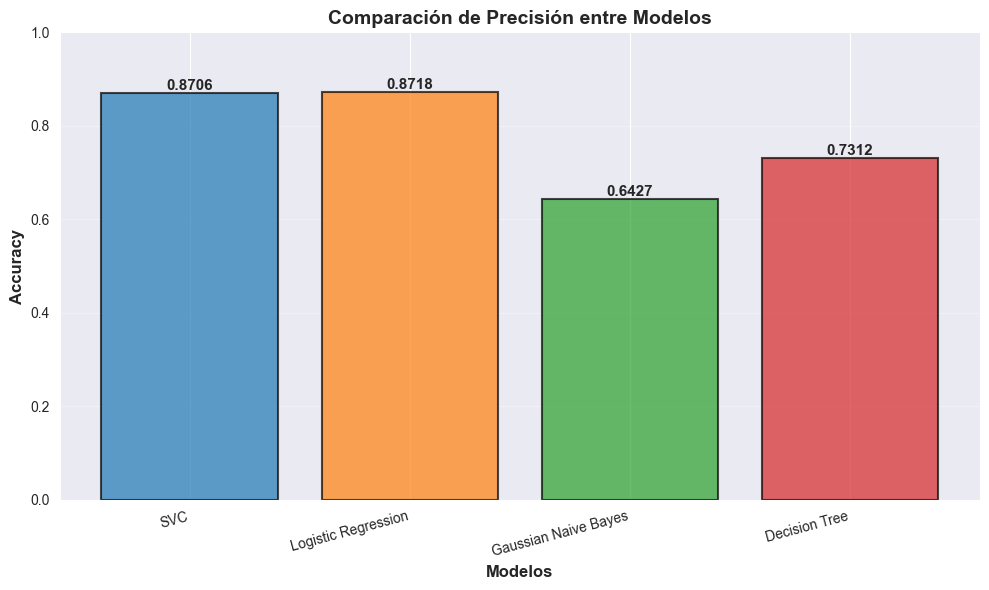


✅ Mejor modelo: Logistic Regression con accuracy de 0.8718


In [54]:
# Gráfico comparativo de precisión de todos los modelos
import matplotlib.pyplot as plt

modelos_nombres = list(resultados.keys())
modelos_accuracy = list(resultados.values())

plt.figure(figsize=(10, 6))
colores = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
barras = plt.bar(modelos_nombres, modelos_accuracy, color=colores, alpha=0.7, edgecolor='black', linewidth=1.5)

# Agregar valores en las barras
for barra in barras:
    altura = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2., altura,
            f'{altura:.4f}',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

plt.ylabel('Accuracy', fontsize=12, fontweight='bold')
plt.xlabel('Modelos', fontsize=12, fontweight='bold')
plt.title('Comparación de Precisión entre Modelos', fontsize=14, fontweight='bold')
plt.ylim(0, 1)
plt.grid(axis='y', alpha=0.3)
plt.xticks(rotation=15, ha='right')
plt.tight_layout()
plt.show()

# Encontrar mejor modelo
mejor_modelo = max(resultados.items(), key=lambda x: x[1])
print(f"\n✅ Mejor modelo: {mejor_modelo[0]} con accuracy de {mejor_modelo[1]:.4f}")

Visualizaciones y Análisis Comparativo

Análisis visual de los modelos y sus características más importantes